# Portfolio optimization on Dirac

#### Device: Dirac-1

## Introduction

This approach seeks to identify a sub-portfolio of stocks that have superior risk-return profiles compared to the full portfolio. This identifies opportunities for an investor to simplify their investment strategy without sacrificing (and potentially enhancing) the risk-adjusted return. While the expected return on a portfolio is relatively straightforward to optimize by itself, optimizing against risk is more subtle when choosing a set of assets that individually have high returns. The reason that optimizing against risk is more challenging is because asset performances can be correlated. Intuitively, one can see that investing in two highly-correlated assets is more risky than if they are uncorrelated or even anti-correlated. If one of a highly correlated asset is performing poorly, the other in the pair is likely to do so as well. Thus, the variance of a portfolio with both assets can be significantly higher than it would be if they were uncorrelated. Minimizing the overall variance for the return of a portfolio therefore needs to take into account the covariance between the assets, making this a fundamentally quadratic problem, ideal for our Dirac-1 solver.

## Importance

Investments need not only give a good return on average, but also need to balance the potential risks. This balance will depend on the goal of the investor. For example, someone investing their retirement fund is likely to favor modest returns with low risks because the consequences of major losses are severe. On the other hand, someone who is day-trading in the hopes of having more money for entertainment might be willing to take more risks. There are of course many other scenarios with other risk levels. In general, the portfolio optimization problem is viewed as being a multi-objective problem. The goal is to balance the objective of maximizing return with the objective of minimizing risk. Even with multiple objectives there is still a sense of optimality, a portfolio is said to be "efficient" or "[Pareto optimal](https://en.wikipedia.org/wiki/Multi-objective_optimizationy)" if the only ways to decrease risk would be to also decrease return. Regardless of one's appetite for risk, it never makes sense to invest in a non-Pareto-Optimal portfolio, so our goal is to find those that are Pareto optimal and match the appetite for risk which is parameterized by a term  $\xi$ in our description. It is worth noting that this tutorial is based on a relatively simplified but still commonly used model of portfolio optimization. Various efforts exist to take into account more complex structure in the distribution of expected returns, in particular [the failure to capture extreme events](http://math.bu.edu/people/murad/pub/hist11-posted.pdf).

## Applications

Portfolios diversification is necessary to achieve satisfactory outcomes for investors, making the kind of portfolio optimization discussed here (and potentially more complex variants) highly important. In spite of its simplicity, the model of diversification presented here, often referred to as [modern portfolio](https://www.britannica.com/money/modern-portfolio-theory-explained) theory, is [still used](https://www.nutmeg.com/nutmegonomics/markowitzs-legacy-why-modern-portfolio-theory-still). Improvements of the models presented here comprise a subject known as [post-modern portfolio theory](http://actuaries.org/AFIR/Colloquia/Orlando/Ferguson_Rom.pdf). One improvement is to consider a quantity known as [downside risk](https://www.lehigh.edu/~xuy219/research/Downside.pdf) instead of variance. Downside risk only takes into account the risk of portfolio elements underperforming a goal, rather than their total variation. Since the goal of diversification is to protect from risk, this approach can yield better performance.

## Methodology

Let K be the total number of available stocks to choose from (here $K = 253$), that is the size of the stock pool. We want to choose a subset of $K^\prime$  ($K^\prime < K$) stocks such that the portfolio risk is minimized, while the portfolio expected return is maximized, that is

$\min_{\{x_{i}\}_{i \in \{1, 2,..., K\}}} [-E(R)^2 + \xi VAR(R)]$

where $R$ is the daily returns of the portfolio over some period of time, $VAR(R)$ and $E(R)$ are the variance and expectation of daily returns, $\xi$ is a hyper-parameter, and $\{x_{i}\}$ are binary variables representing inclusion or exclusion of a stock. A large value means the focus of optimization is to increase return, whereas a small value indicates the reduction of risk is more important. As we can take both long and short positions on stocks, we assume that $x_1, x_2, ..., x_K$ corresponds to long positions on stocks 1 to $K$. 

As we are choosing a subset of $K^\prime$ stocks, we also need the following constraint,

$\sum_{i=1}^{K} x_i = K^\prime$

Assuming that the same amount is invested on each of the K' selected stocks, the portfolio daily return at time t over a time period denoted by m can be expanded as follows,

$R^{(m)}(t) =\frac{1}{K^\prime} \sum_{i=1}^{K} x_i r^{(m)}_i(t)$

where $r^{(m)}_i(t)$ is the daily return of stock i at time $t$ in time period $m$. The expectation of portfolio daily return over time period $m$ can thus be expanded as,

$E(R^{(m)}) = \frac{1}{K^\prime} \sum_{i=1}^{K} x_i E(r^{(m)}_i)$

and the variance portfolio daily return over time period m is expanded as,

$VAR(R^{(m)}) = \frac{1}{K^{\prime 2}} \sum_{i=1}^{K} \sum_{j=1}^{K} x_i x_j COV(r^{(m)}_i, r^{(m)}_j)$

where $COV$ is the covariant function. 

The problem then reduces to

$\min_{\{x_i\}} {\bf{x}^T} \frac{1}{K^{\prime 2}} [ Q^{(m)} - \xi  P^{(m)}] {\bf{x}}$

where

$Q^{(m)}_{ij} = COV(r^{(m)}_{i},  r^{(m)}_{j})$

$P^{(m)}_{ij}= E(r_i^{(m)}) \delta_{ij}$

To avoid an over-fit on the portfolio data, we can minimize the average of the cost function over $M$ overlapping time periods, that is $m=1,2,...,M$. The problem becomes,

$\min_{\{x_i\}} {\bf{x}^T} \frac{1}{MK^{\prime 2}} \sum_{m=1}^{M}[ Q^{(m)} - \xi  P^{(m)}] {\bf{x}}$

subject to,

$\sum_{i=1}^{K} x_i = K^\prime$


## Binary Optimization Method using Dirac 1
Binary optimization simplifies investment decisions by selecting specific stocks for a portfolio while excluding others. Each stock is represented by a binary variable $x_i$:

- $x_i = 0$  means the stock is not chosen.
- $x_i = 1$ means the stock is chosen, where $i$ is the index of the stock.

This method helps investors carefully pick and allocate assets to manage risk and achieve desired portfolio outcomes effectively.

### Example

Imagine you have $5$ stocks to choose from, and you want to select $3$ of them for your portfolio to maximize returns while minimizing risk.  We run this problem on our **Dirac-1** machine.

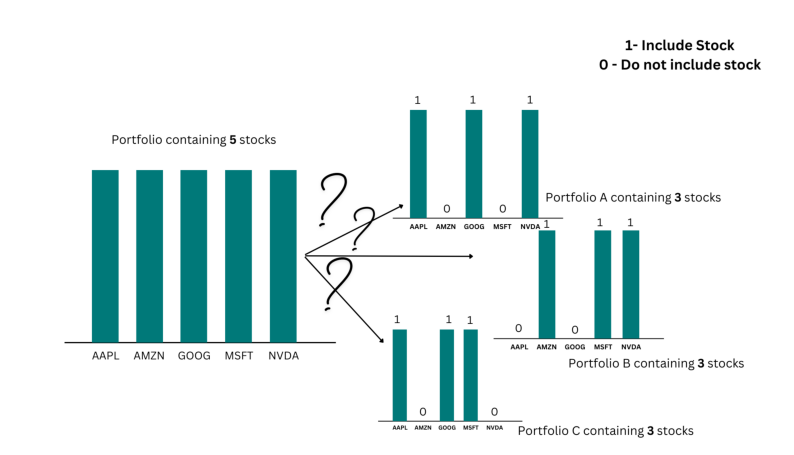



| Company | Symbol|
|:--------:|:--------:|
|  Microsoft Corp |  MSFT	   |
|  Apple Inc	   |  AAPL	   |
|  Amazon.com Inc   |  AMZN	   |
|  Alphabet Inc   |  GOOG	  |
|  NVIDIA Corp   | NVDA  |




We want to use binary optimization to select the best $3$ stocks out of $5$ available options for our portfolio.

 **Define Binary Variables**

We define a binary variable $x_i$ for each stock  $i$ :

-  $x_1$  for Microsoft Corp (MSFT)
-  $x_2$  for Apple Inc (AAPL)
-  $x_3$  for Amazon.com Inc (AMZN)
-  $x_4$  for Alphabet Inc (GOOG)
-  $x_5$  for NVIDIA Corp (NVDA)

Each  $x_i$  can take values:
- $0$  means the stock is not included in the portfolio.
-  $1$  means the stock is included in the portfolio.

**Constraint**

We need exactly $3$ stocks in the portfolio, so the sum of the binary variables should be $3$:

 $x_1 + x_2 + x_3 + x_4 + x_5 = 3$

 **Objective**


Our goal is to maximize the portfolio returns while minimizing risk.








In our tutorial, we have historical datasets containing stock prices over a period of time. Our goal is to use these datasets to calculate important metrics such as [the rate of return](https://en.wikipedia.org/wiki/Rate_of_return), [expected return](https://en.wikipedia.org/wiki/Expected_return), [variance](https://en.wikipedia.org/wiki/Variance), and [covariance](https://en.wikipedia.org/wiki/Covariance). By calculating these metrics for each stock in our portfolio, we gain insights into their performance and risk characteristics. Expected return helps us gauge potential profitability, variance quantifies the risk associated with individual stocks, and covariance indicates how stocks move relative to each other. These calculations are essential for making informed investment decisions aimed at optimizing returns while managing risk effectively.


Let us begin by formulating the math.

We define the following variables as:

**1. K:** Total number of available stocks in given portfolio. In our example, **K** $= 5$

**2. K':** Number of stocks to select for our optimized portfolio. In our example, **K'** $= 3$

**3. R:** Daily returns or the Returns per Day of the portfolio

**4. E(R):** Expected Return of the portfolio

**5. Var(R):** Variance of returns

**6. ξ (xi):** A parameter that balances the importance of maximizing returns versus minimizing risk.

**7. $x_i$:** Binary variable indicating whether stock i is included in the portfolio.

Now, we can define our **Objective Function**, i.e, the function that encapsulates the goal of constructing a portfolio that balances maximizing expected returns and minimizing risk.   as follows:




$$
\text{minimize} [ -E(R)^{2} + ξ*Var(R) ]
$$

This can be simplified to:

$$
\text{minimize} [ - P + ξQ ]
$$


Where $P$ and $Q$ represent the matrices of expected returns and [covariance](https://en.wikipedia.org/wiki/Covariance_matrix) respectively.



### Constructing the Hamiltonian (H)

In optimization, the Hamiltonian is constructed to encapsulate both the objective and the constraints. For this problem:

$ H = -P + ξQ$

Before we begin, you'll need your unique token to access the QCi Client API and connect to the Dirac device. If you don't have a token yet, you can sign up for our [Free Trial Cloud Access](https://quantumcomputinginc.com/learn/tutorials-and-use-cases/quick-start-on-cloud)). Let's get started!

You can download the data sets and get access to the full code base [here](https://github.com/cvadlamani/portfolio_optimization)

## Run () method

The [run function](https://github.com/cvadlamani/portfolio_optimization/blob/main/run.py) is the main function designed to perform portfolio optimization algorithm by historical data up to the current date to select stocks expected to perform well going forward.

It does three main things: first, it looks at how stocks have performed historically (in-sample returns). Then, it constructs a Hamiltonian matrix to balance returns and risks. Finally, it selects the optimal set of stocks for a given current date. The function ultimately returns a DataFrame of the selected stocks and the date on which the selection was made. Let's dive deeper into this function

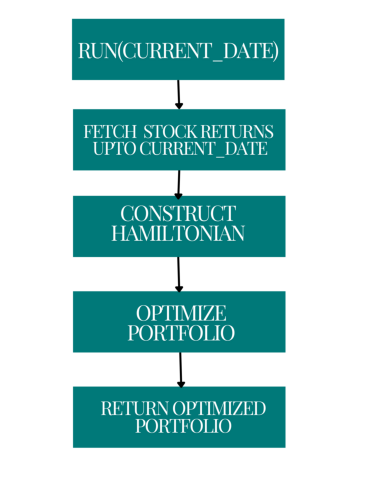

### Step 1

* Retrieve the historical return data for the in-sample period. This data is used to estimate the expected returns and risks of the stocks. The data covers the period leading up to the current date.




In [3]:
'''
Converts the current date to a datetime object and calculates the start and end dates for the in-sample
and out-of-sample periods based on the IN_SAMPLE_DAYS
'''
import pandas as pd
import datetime
from parameters import IN_SAMPLE_DAYS
from get_stock_returns import get_stock_returns

#define your file path
file_path = r"company_stock_data.csv"

# Convert current date to datetime object
current_date = pd.to_datetime(current_date)

# Calculate in-sample date ranges
in_sample_start_date = current_date - datetime.timedelta(days=IN_SAMPLE_DAYS)
in_sample_end_date = current_date - datetime.timedelta(days=1)

# Read stock data from CSV file and extract unique stock symbols
file_path = FILE_PATH
df = pd.read_csv(file_path)
stocks = list(set(df["Symbol"]))

# Retrieve stock return data for in-sample and out-of-sample periods
in_sample_returns_df = get_stock_returns(stocks, in_sample_start_date, in_sample_end_date)


# Sort return data by date and fill missing values
in_sample_returns_df = in_sample_returns_df.sort_values("Date")
in_sample_returns_df = in_sample_returns_df.fillna(method="ffill").fillna(0)

ModuleNotFoundError: No module named 'parameters'

### Step 2

* Construct the Hamiltonian matrix using the in-sample return data. This matrix combines the expected returns and the covariance of returns, forming the basis for the optimization objective function.

```python
#Calculates the Hamiltonian matrix based on the in-sample return data and the date range.
hamiltonian_matrix = get_hamiltonian(in_sample_returns_df, stocks, in_sample_start_date,in_sample_end_date)


### Step 3

* Optimize the portfolio by selecting the stocks that provide the best balance between expected return and risk, based on the Hamiltonian matrix.

```python
#Uses the Hamiltonian matrix to find the optimal set of stocks.
selected_stocks = optimize_portfolio(hamiltonian_matrix, stocks )


### Step 4

* Create a DataFrame containing the selected stocks and store it in a csv file.
```python
  if os.path.exists(SEL_STOCK_OUT_FILE):
        selected_stocks_df.to_csv(
            SEL_STOCK_OUT_FILE, index=False, mode="a", header=False,
        )
    else:
        selected_stocks_df.to_csv(
            SEL_STOCK_OUT_FILE, index=False,
        )
  #Creates a DataFrame to store the selected stocks.
  selected_stocks_df = pd.DataFrame()
  selected_stocks_df["Date"] = [current_date ] * len(selected_stocks)


Ou result JSON file contains the following fields:

```python
{
  "job_info": {
    "job_id": "66747205450099160ba0be88",
    "job_submission": {
      "job_name": "Portfolio Optimization",
      "job_tags": [
        "portfolio stock optimization"
      ],
      "problem_config": {
        "quadratic_linearly_constrained_binary_optimization": {
          "constraints_file_id": "6674720598263204a365de67",
          "objective_file_id": "6674720498263204a365de65",
          "alpha": 1,
          "atol": 1e-10
        }
      },
      "device_config": {
        "dirac-1": {
          "num_samples": 5
        }
      }
    },
    "job_status": {
      "submitted_at_rfc3339nano": "2024-06-20T18:16:37.616Z",
      "queued_at_rfc3339nano": "2024-06-20T18:16:37.617Z",
      "running_at_rfc3339nano": "2024-06-20T18:19:31.826Z",
      "completed_at_rfc3339nano": "2024-06-20T18:20:40.12Z"
    },
    "job_result": {
      "file_id": "667472f898263204a365de6f",
      "device_usage_s": 68
    }
  },
  "status": "COMPLETED",
  "results": {
    "counts": [5],
    "energies": [-8.993657729952648],
    "feasibilities": [true],
    "objective_values": [0.0063417898174550425],
    "solutions": [
      [1, 1, 0, 0, 1]
    ]
  }
}




Where:

- **job_info**: Contains all the information about the job.
  - **job_id**: A unique identifier for the job (`66747205450099160ba0be88`).
  - **job_submission**: Details about the job submission.
    - **job_name**: The name of the job (`Portfolio Optimization`).
    - **job_tags**: Tags associated with the job (e.g., `portfolio stock optimization`).
    - **problem_config**: Configuration of the problem to be solved.
      - **quadratic_linearly_constrained_binary_optimization**: Specifies that the problem is a quadratic linearly constrained binary optimization.
        - **constraints_file_id**: ID of the file containing the constraints (`6674720598263204a365de67`).
        - **objective_file_id**: ID of the file containing the objective function (`6674720498263204a365de65`).
        - **alpha**: A parameter used in the optimization (value: 1).
        - **atol**: Absolute tolerance for the optimization (value: 1e-10).
    - **device_config**: Configuration of the device used for the job.
      - **dirac-1**: Specifies the device used (`dirac-1`).
        - **num_samples**: Number of samples taken (value: 5).
  - **job_status**: Status updates of the job.
    - **submitted_at_rfc3339nano**: Time when the job was submitted (`2024-06-20T18:16:37.616Z`).
    - **queued_at_rfc3339nano**: Time when the job was queued (`2024-06-20T18:16:37.617Z`).
    - **running_at_rfc3339nano**: Time when the job started running (`2024-06-20T18:19:31.826Z`).
    - **completed_at_rfc3339nano**: Time when the job completed (`2024-06-20T18:20:40.12Z`).
  - **job_result**: Results of the job.
    - **file_id**: ID of the file containing the job result (`667472f898263204a365de6f`).
    - **device_usage_s**: Time the device was used, in seconds (value: 68).
- **status**: The current status of the job (`COMPLETED`).
- **results**: The outcomes of the job.
  - **counts**: Number of samples taken for each solution (value: [5]).
  - **energies**: Energies of the solutions (value: [-8.993657729952648]).
  - **feasibilities**: Whether the solutions are feasible (value: [True]).
  - **objective_values**: Objective values of the solutions (value: [0.0063417898174550425]).
  - **solutions**: The actual solutions found (value: [[1, 1, 0, 0, 1]]).

## Understanding the Results
Each portfolio can be represented as a $5$-bit binary string, where each bit indicates whether a specific stock is included in the portfolio or not. For example, given the stock list:

 **[AAPL, AMZN, GOOG, MSFT, NVDA]**:

- A binary string of $11010$ means:
  - AAPL is included $(1)$
  - AMZN is included $(1)$
  - GOOG is not included $(0)$
  - MSFT is included $(1)$
  - NVDA is not included $(0)$

### Step 5

* From the result json display the selected stocks that from the optimized portfolio.
```python
print("Optimized portfolio contains the following stocks:")
    display(HTML(selected_stocks_df[["Stock"]].tail(1).to_html()))


## Optimial Portfilio Selected:

When we run our code, we will see that the optimal portfolio contains these 3 stocks:

<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Stock</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>AAPL</td>
    </tr>
    <tr>
      <th>1</th>
      <td>AMZN</td>
    </tr>
    <tr>
      <th>2</th>
      <td>MSFT</td>
    </tr>
  </tbody>
</table>

## Visualizing Optimal Portfolio Selected by Dirac-1

We are plotting the energy landscape values for different combinations of a portfolio that includes $3$ out of the $5$ possible stocks. This graph illustrates how **Dirac-1** identifies the portfolio with the lowest energy value among all combinations. The true minimum value labeled on the graph was determined by exhaustive search, and we compare it with the results from **Dirac-1**.

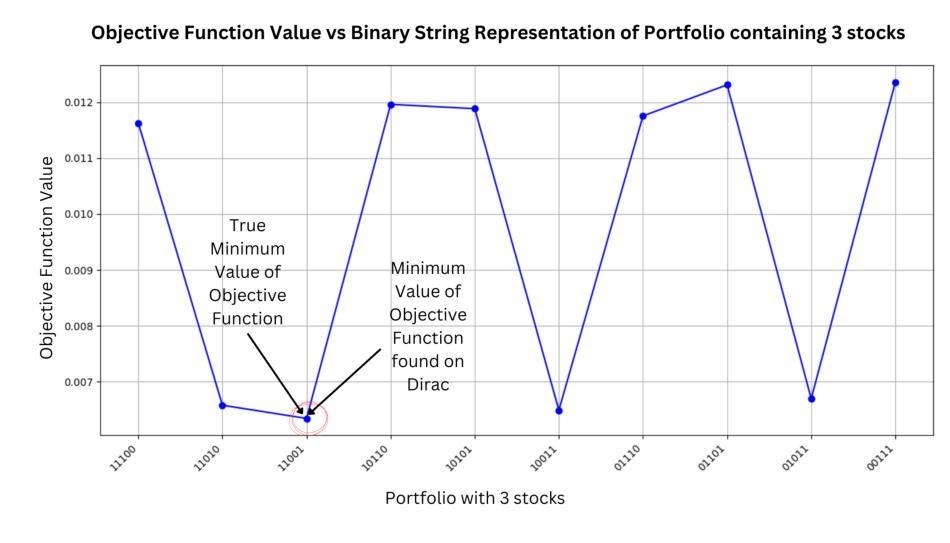

## Conclusion

In conclusion, we observe that **Dirac-1** effectively finds the exact solution and successfully solves the portfolio optimization problem. For a more challenging and comprehensive use case, refer to our example tutorial on optimizing a 100-asset portfolio using the Nasdaq-100 to form an optimal portfolio containing 30 stocks as a benchmark with the **Dirac-**1 machine. Click [here](https://github.com/qci-enablement/qci-data/blob/main/learn/tutorials-and-use-cases/nasdaq100_stocks.csv) to learn more.


### Next: Portfolio Optimization using Continuous Optimization on Dirac-3

##Citations
[1] H. Markowitz,  [ The Journal of Finance 7, 77 (1952).](https://www.jstor.org/stable/2975974).

[2] Wolfgang Sakuler et al. A real world test of Portfolio Optimization with Quantum Annealing. 2023.
arXiv:[2303.12601 [quant-ph].](https://arxiv.org/abs/2303.12601)

[3] Jeffrey Cohen, Alex Khan, and Clark Alexander. Portfolio Optimization of 60 Stocks Using
Classical and Quantum Algorithms. 2020. arXiv: [2008.08669 [q-fin.GN]](https://arxiv.org/abs/2008.08669)

[4] Frank Phillipson and Harshil Singh Bhatia. “Portfolio Optimisation Using the D-Wave Quantum
Annealer”. In: Computational Science – ICCS 2021. Ed. by Maciej Paszynski et al. Cham: Springer
International Publishing, 2021, pp. 45–59. ISBN: 978-3-030-77980-1.

[5] S. Brandhofer, D. Braun, and V. Dehn. “Benchmarking the performance of portfolio optimization
with QAOA”. In: Quantum Inf Process (2023)